In [93]:
import pandas as pd
import numpy as np

#librerias de visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = ["Noto Sans", "Noto Sans CJK JP"]

df = pd.read_csv("../Data/Raw/Output/03_data_limpio.csv", parse_dates=["timestamp", "release_date"])

In [2]:
df.shape

(70000, 34)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   userId                70000 non-null  int64         
 1   movieId               70000 non-null  int64         
 2   rating                70000 non-null  float64       
 3   timestamp             70000 non-null  datetime64[ns]
 4   title                 70000 non-null  str           
 5   genres_x              70000 non-null  str           
 6   imdbId                70000 non-null  int64         
 7   tmdbId                70000 non-null  int64         
 8   budget                70000 non-null  int64         
 9   genres_y              70000 non-null  str           
 10  homepage              28911 non-null  str           
 11  id                    70000 non-null  int64         
 12  keywords              70000 non-null  str           
 13  original_language     70000

Revision de columnas redundantes

In [4]:
df[["title", "original_title", "title_x", "title_y"]].head()

,title,original_title,title_x,title_y
0,Pulp Fiction (1994),Pulp Fiction,Pulp Fiction,Pulp Fiction
1,Singin' in the Rain (1952),Singin' in the Rain,Singin' in the Rain,Singin' in the Rain
2,"Bridge on the River Kwai, The (1957)",The Bridge on the River Kwai,The Bridge on the River Kwai,The Bridge on the River Kwai
3,Gattaca (1997),Gattaca,Gattaca,Gattaca
4,Back to the Future Part II (1989),Back to the Future Part II,Back to the Future Part II,Back to the Future Part II


In [5]:
df["release_year"].head()

0    1994
1    1952
2    1957
3    1997
4    1989
Name: release_year, dtype: int64

Dado que tenemos la columna "release_year", la columna title que tiene el titulo y el año no nos hace falta, por lo que nos quedaremos con "original_title"

In [6]:
df[["genres_x", "genres_y"]].head()

,genres_x,genres_y
0,Comedy|Crime|Drama|Thriller,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 80, ""n..."
1,Comedy|Musical|Romance,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10402, ""..."
2,Adventure|Drama|War,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 36, ""name..."
3,Drama|Sci-Fi|Thriller,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 878, ""..."
4,Adventure|Comedy|Sci-Fi,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 35, ""..."


Con las columnas de "genre" vemos que "genres_y" tiene demasiada información - por lo que será esta la columna a eliminar. Mientras que la columna de "genres_x" igualmente conserva varios generos, por lo que se creará una columna adicional con "main_genre" que conserve el primero.

In [7]:
df[["id", "movie_id", "tmdbId"]].head()

,id,movie_id,tmdbId
0,680,680,680
1,872,872,872
2,826,826,826
3,782,782,782
4,165,165,165


In [8]:
(df["tmdbId"].astype(int)) == df["id"].astype(int).all

0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Name: tmdbId, Length: 70000, dtype: bool

In [9]:
(df["movie_id"].astype(int)) == df["id"].astype(int).all

0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Name: movie_id, Length: 70000, dtype: bool

In [10]:
(df["movie_id"].astype(int)) == (df["tmdbId"].astype(int)) 

0        True
1        True
2        True
3        True
4        True
         ... 
69995    True
69996    True
69997    True
69998    True
69999    True
Length: 70000, dtype: bool

In [11]:
df[df["tmdbId"]!= df["id"]][["tmdbId", "id", "title_x"]].head(20)

,tmdbId,id,title_x


Tras la comprobacion de las columasn "tmdbId", "id", movie_id no se ha podido asegurar que estas representen la misma clave para cada valor, por lo que no borraremos por ahora ninguna de las 3 y posteriormente veremos cuales aportan valor y cuales no para eliminar aquella innecesaria

Eliminación de las columnas duplicadas revisadas

In [12]:
df_1 = df.copy()

In [13]:
columnas_repetidas = ["title", "title_x", "title_y","genres_y"]

In [14]:
df_1.drop(columns=columnas_repetidas, inplace=True)

In [15]:
df_1.shape

(70000, 30)

Del noteboook previo: Las columnas: "keywords", spoken_languages, status, tagline, cast, crew, homepage - no aportan informacion relevante para el análisis. Las revisamos antes de eliminarlas.

In [16]:
cols_review = ["keywords", "spoken_languages", "status", "tagline", "cast", "crew"]


In [17]:
revision_cols = pd.DataFrame({"columna": cols_review,
                              "valores_unicos": [df_1[col].nunique()for col in cols_review],
                              "nulos": [df_1[col].isna().sum()for col in cols_review]})

display(revision_cols)

,columna,valores_unicos,nulos
0,keywords,3387,0
1,spoken_languages,477,0
2,status,1,0
3,tagline,3198,2525
4,cast,3544,0
5,crew,3544,0


In [18]:
df[["spoken_languages", "original_language"]].head()

,spoken_languages,original_language
0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",en
1,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",en
2,"[{""iso_639_1"": ""ja"", ""name"": ""\u65e5\u672c\u8a...",en
3,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",en
4,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",en


In [19]:
df[["spoken_languages", "original_language"]].nunique()

spoken_languages     477
original_language     28
dtype: int64

Aunque los valores unicos entre "spoken_languages", "original_language" no sean los mismos, consideramos que la columna de spoken language da informacion adicional no relevante para el análisis, por lo que se eliminará. 

De "crew" y "cast" nos quedamos con director y main_caracter

In [20]:
print(df_1["cast"].iloc[1])

[{"cast_id": 14, "character": "Don Lockwood", "credit_id": "52fe4285c3a36847f80256f9", "gender": 2, "id": 13294, "name": "Gene Kelly", "order": 0}, {"cast_id": 15, "character": "Cosmo Brown", "credit_id": "52fe4285c3a36847f80256fd", "gender": 2, "id": 13295, "name": "Donald O'Connor", "order": 1}, {"cast_id": 16, "character": "Kathy Selden", "credit_id": "52fe4285c3a36847f8025701", "gender": 1, "id": 8857, "name": "Debbie Reynolds", "order": 2}, {"cast_id": 17, "character": "Lina Lamont", "credit_id": "52fe4285c3a36847f8025705", "gender": 1, "id": 13296, "name": "Jean Hagen", "order": 3}, {"cast_id": 18, "character": "R.F. Simpson", "credit_id": "52fe4285c3a36847f8025709", "gender": 2, "id": 13297, "name": "Millard Mitchell", "order": 4}, {"cast_id": 26, "character": "Dancer", "credit_id": "52fe4285c3a36847f8025729", "gender": 1, "id": 41226, "name": "Cyd Charisse", "order": 5}, {"cast_id": 19, "character": "Roscoe Dexter", "credit_id": "52fe4285c3a36847f802570d", "gender": 0, "id": 13

In [21]:
import ast

In [22]:
cast_0= ast.literal_eval(df_1["cast"].iloc[0])

In [23]:
cast_0[0]["name"]

'John Travolta'

In [24]:
def extract_main_actor(cast_text):
    try:
        return ast.literal_eval(cast_text)[0]["name"]
    except:
        return None


In [25]:
df_1["main_actor"] = df_1["cast"].apply(extract_main_actor)

In [26]:
df_1[["original_title", "main_actor"]].head(5)

,original_title,main_actor
0,Pulp Fiction,John Travolta
1,Singin' in the Rain,Gene Kelly
2,The Bridge on the River Kwai,William Holden
3,Gattaca,Ethan Hawke
4,Back to the Future Part II,Michael J. Fox


In [27]:
df_1["main_actor"].isnull().sum()

np.int64(3)

In [28]:
crew_0 = ast.literal_eval(df_1["crew"].iloc[0])


In [29]:
for person in crew_0:
    if person["job"]== "Director":
        print(person["name"])

Quentin Tarantino


In [30]:
def extract_director (crew_text):
    try:
        crew_list = ast.literal_eval(crew_text)
        for person in crew_list:
            if person["job"] == "Director":
                return person["name"]
        return None 
    except:
        return None


In [31]:
df_1["director"] = df_1["crew"].apply(extract_director)

In [32]:
df_1["director"].isnull().sum()

np.int64(0)

Hacemos la misma limpieza para production_countries y production_companies

In [33]:
company_0 =ast.literal_eval(df_1["production_companies"].iloc[0]
                            )
company_0[0]["name"]

'Miramax Films'

In [34]:
def extract_first_name(text):
    try: 
        return ast.literal_eval(text)[0]["name"]
    except:
        return None

In [35]:
df_1["main_company"] = (df_1["production_companies"].apply(extract_first_name))

In [36]:
df_1["main_country"] = (df_1["production_countries"].apply(extract_first_name))

In [37]:
df_1["main_country"].isnull().sum()

np.int64(25)

In [38]:
df_1["main_company"].isnull().sum()

np.int64(160)

Comprobamos los nulos

In [39]:
df_1[df_1["main_company"].isna()][["production_companies"]].head(10)

,production_companies
1337,[]
1497,[]
1549,[]
1609,[]
1645,[]
1647,[]
1655,[]
1656,[]
1889,[]
2901,[]


In [40]:
df_1["main_company"].head(10)

0                    Miramax Films
1        Metro-Goldwyn-Mayer (MGM)
2    Columbia Pictures Corporation
3                Columbia Pictures
4               Universal Pictures
5               Universal Pictures
6     Producers Sales Organization
7                   Adela Pictures
8            X-Filme Creative Pool
9       Silver Screen Partners III
Name: main_company, dtype: str

In [41]:
df_1[df_1["main_country"].isna()][["production_countries"]].head(10)

,production_countries
2901,[]
3453,[]
5494,[]
9559,[]
9831,[]
10795,[]
10838,[]
10873,[]
11044,[]
13936,[]


In [42]:

df_1[df_1["main_actor"].isna()][["cast"]].head()

,cast
1645,[]
9800,[]
58652,[]


Vemos que en los datos que hay como nulos en las 3 columnas que hemos hecho es porque no está el dato, por lo que consideramos conveniente cambiar esto por "unknown"

In [43]:
columnas_fill_unknown = ["main_actor", "main_country", "main_company"]

In [44]:
for col in columnas_fill_unknown:
    df_1[col] = df_1[col].fillna("Unknown")

Ahora podemos eliminar tanto las columnas originales de estas nuevas creadas, como el resto de columnas que hemos visto que no aportan informacion

In [45]:
df_2 = df_1.copy()

In [46]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   userId                70000 non-null  int64         
 1   movieId               70000 non-null  int64         
 2   rating                70000 non-null  float64       
 3   timestamp             70000 non-null  datetime64[ns]
 4   genres_x              70000 non-null  str           
 5   imdbId                70000 non-null  int64         
 6   tmdbId                70000 non-null  int64         
 7   budget                70000 non-null  int64         
 8   homepage              28911 non-null  str           
 9   id                    70000 non-null  int64         
 10  keywords              70000 non-null  str           
 11  original_language     70000 non-null  str           
 12  original_title        70000 non-null  str           
 13  overview              70000

In [47]:
df_2.drop(columns= ["spoken_languages", "production_companies", "production_countries", "cast", "crew", "status", "tagline", "overview"], inplace =True)                                

In [48]:
df_2.shape

(70000, 26)

In [49]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  int64         
 1   movieId            70000 non-null  int64         
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[ns]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  int64         
 6   tmdbId             70000 non-null  int64         
 7   budget             70000 non-null  int64         
 8   homepage           28911 non-null  str           
 9   id                 70000 non-null  int64         
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     

Nos quedaria hacer una columna con el genero principal pero manteniendo la columna de genero principal

In [50]:
df_2["main_genre"] = (df_2["genres_x"].str.split("|").str[0])

In [51]:
df_2["main_genre"].head(10)

0       Comedy
1       Comedy
2    Adventure
3        Drama
4    Adventure
5    Adventure
6    Adventure
7        Drama
8       Action
9       Comedy
Name: main_genre, dtype: object

Revision de nulos: aunque la columna budget y revenue no tienen nulos, tienen valores 0 

In [52]:
(df_2["budget"] == 0).sum()

np.int64(2309)

In [53]:
(df_2["budget"]==0).mean()*100

np.float64(3.2985714285714285)

In [54]:
df_2["budget"] = (df_2["budget"].replace(0, np.nan))

In [55]:
(df_2["revenue"] == 0).sum()

np.int64(3674)

In [56]:
(df_2["revenue"]==0).mean()*100

np.float64(5.248571428571429)

A pesar de que en el caso de "revenue" si podria existir la opcion de que haya tenido 0€ de ingresos, vamos a considerar que igualmente el valor 0 es desconocido, ya que podria dar un resultado en profit de valor negativo demasiado bajo

In [57]:
df_2["revenue"] = (df_2["revenue"].replace(0, np.nan))

Ahora creamos las columnas ROI y profit para más adelante hacer operaciones con estas

In [58]:
df_2["profit"] = (df_2["revenue"]- df_2["budget"])

In [59]:
df_2["roi"] = (df_2["profit"]/df_2["budget"])

In [60]:
df_2["roi"].isnull().sum()

np.int64(4325)

In [61]:
df_2["profit"].isnull().sum()

np.int64(4325)

In [62]:
nulos= df_2.isna().mean()*100
nulos.sort_values(ascending=False)

homepage             58.698571
profit                6.178571
roi                   6.178571
revenue               5.248571
budget                3.298571
genres_x              0.000000
timestamp             0.000000
tmdbId                0.000000
imdbId                0.000000
id                    0.000000
rating                0.000000
movieId               0.000000
userId                0.000000
original_title        0.000000
original_language     0.000000
keywords              0.000000
popularity            0.000000
vote_average          0.000000
vote_count            0.000000
release_date          0.000000
runtime               0.000000
release_year          0.000000
movie_id              0.000000
rating_year           0.000000
main_actor            0.000000
main_company          0.000000
director              0.000000
main_genre            0.000000
main_country          0.000000
dtype: float64

Volvemos a cambiar las columnas relacionadas con id a tipo str para poder visualizar correctamente


In [63]:
#cambiamos la columna "tmsbId" de tipo float a tipo int
df_2["tmdbId"] = df_2["tmdbId"].astype(int)

In [64]:
id_columns = ["userId", "movie_id", "imdbId", "tmdbId", "movieId", "id"]
for col in id_columns:
    df_2[col] = df_2[col].astype(str)

In [65]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  str           
 1   movieId            70000 non-null  str           
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[ns]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  str           
 6   tmdbId             70000 non-null  str           
 7   budget             67691 non-null  float64       
 8   homepage           28911 non-null  str           
 9   id                 70000 non-null  str           
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     

Visualización columnas numéricas

In [66]:
columnas_numericas = df_2.select_dtypes(include=['number']).columns
columnas_numericas

Index(['rating', 'budget', 'popularity', 'revenue', 'runtime', 'vote_average',
       'vote_count', 'release_year', 'rating_year', 'profit', 'roi'],
      dtype='str')

In [67]:
def subplot_col_num (dataframe):
    col_nums = dataframe.select_dtypes(include="number").columns
    num_graph = len(col_nums)
    num_rows = (num_graph + 2)// 2

    fig, axes = plt.subplots(num_graph, 2, figsize=(15, num_rows*5))

    for i, col in enumerate(col_nums):
        sns.histplot(data=dataframe, x=col, ax=axes[i,0], bins=200)
        axes[i,0].set_title(f"Distribución de {col}")
        axes[i,0].set_xlabel(col)
        axes[i,0].set_ylabel("Frecuencia")

        sns.boxplot(data=dataframe, x=col, ax =axes[i,1])
        axes[i,1].set_title(f"Boxplot de {col}")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

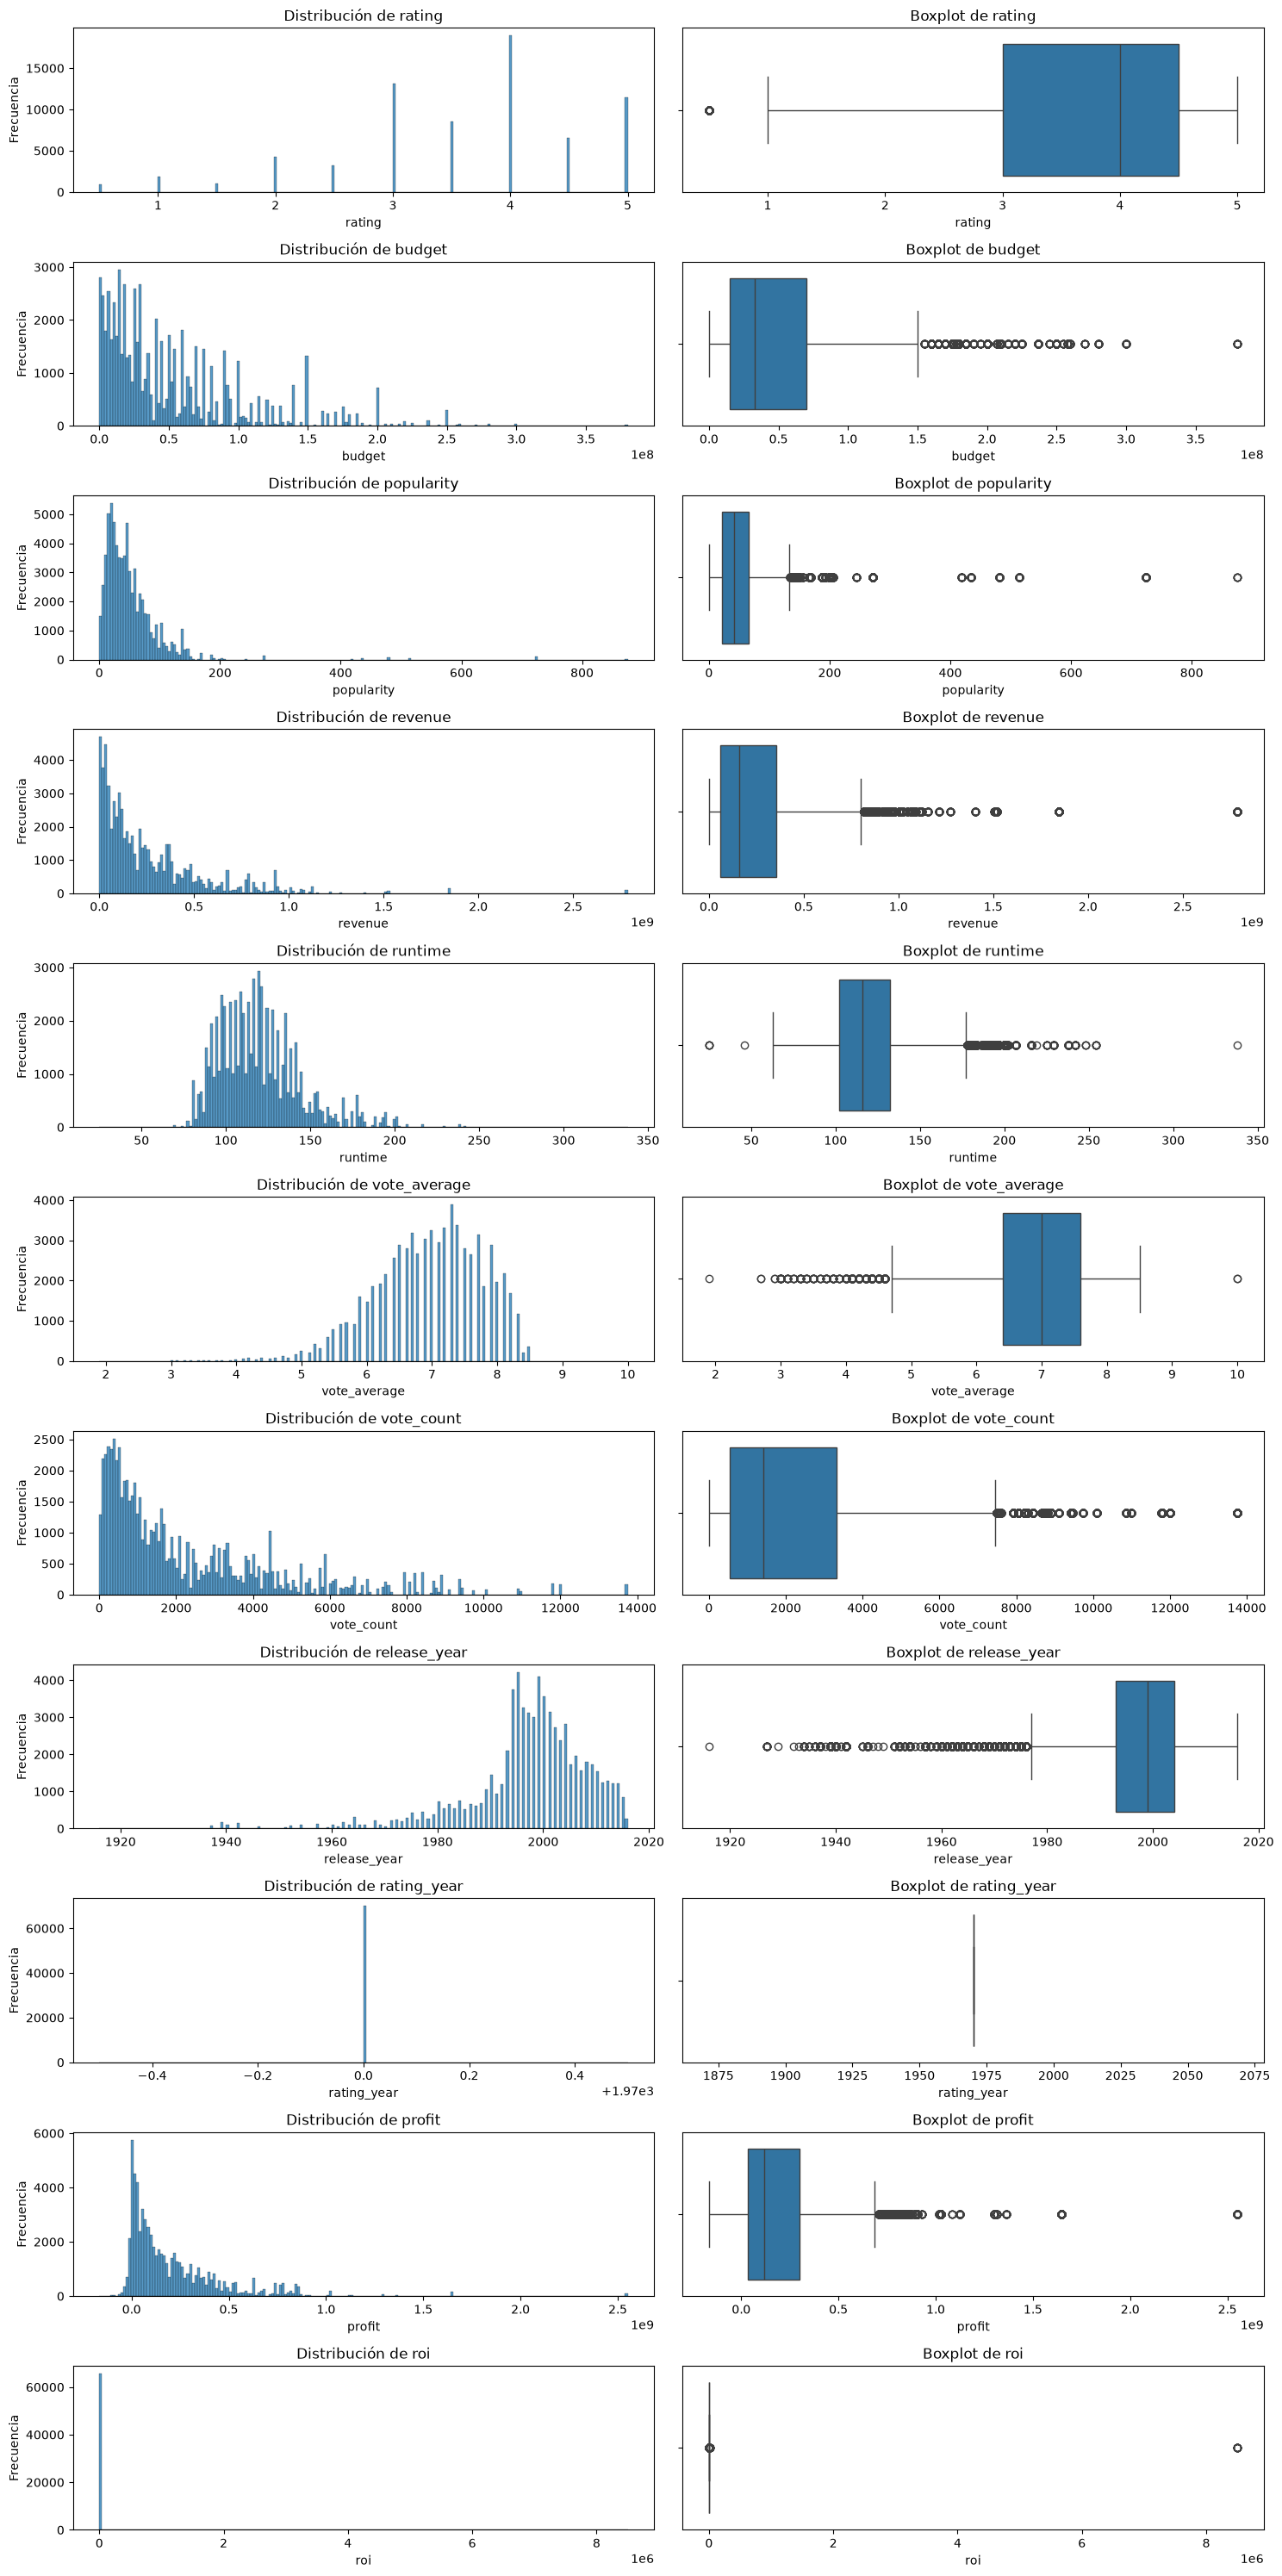

In [68]:
subplot_col_num (df_2)

* Interpretación por variable*

*rating*
La distribución de las valoraciones se concentra principalmente entre 3 y 5 puntos, con una mayor frecuencia en torno a 4. Esto indica una valoración generalmente positiva de las películas de la muestra. La distribución es discreta debido a que las valoraciones se realizan en incrementos de 0,5 puntos.


*budget*
La distribución del presupuesto presenta un marcado sesgo hacia la derecha. La mayoría de las películas tienen presupuestos relativamente moderados, mientras que un número reducido de grandes producciones presenta presupuestos excepcionalmente elevados.


*popularity*
La popularidad presenta un marcado sesgo positivo. La mayor parte de las películas se concentra en valores relativamente bajos, mientras que un número reducido presenta niveles de popularidad excepcionalmente elevados.


*revenue*
Los ingresos presentan una distribución fuertemente asimétrica hacia la derecha. La mayoría de las películas registra ingresos relativamente moderados, mientras que un grupo reducido alcanza niveles de recaudación excepcionalmente elevados.


*runtime*
La duración presenta una distribución relativamente concentrada, principalmente entre 90 y 140 minutos, con una ligera asimetría hacia la derecha debido a la existencia de películas especialmente largas. También aparecen algunos valores extremos que deberán revisarse para comprobar que sean razonables.


*vote_average*
La valoración media de TMDB se concentra principalmente entre 6 y 8 puntos, con un centro cercano a 7. La distribución muestra una concentración clara en valoraciones medias-altas.


*vote_count*
El número de votos presenta una fuerte asimetría hacia la derecha. La mayoría de las películas cuenta con un número relativamente reducido de votos, mientras que un grupo menor concentra miles de votos y presenta valores excepcionalmente elevados.


*release_year*
La distribución muestra una mayor concentración de películas estrenadas desde las últimas décadas del siglo XX hasta la década de 2010, con una presencia considerablemente menor de películas más antiguas.


*rating_year* 
La transformación procedente de "timestamp" no ha sido la correcta por lo que habrá que modificar de nuevo el dato.


*profit*
El beneficio presenta una distribución fuertemente asimétrica hacia la derecha. La mayoría de las películas se concentra en niveles de beneficio relativamente bajos, mientras que un grupo reducido obtiene beneficios excepcionalmente elevados. También existen películas con beneficios negativos, correspondientes a casos en los que los ingresos registrados son inferiores al presupuesto.


*roi*
El ROI presenta una distribución extremadamente asimétrica, con la mayoría de los valores concentrados en niveles bajos y algunos valores excepcionalmente elevados. Estos valores extremos pueden estar relacionados con películas que obtuvieron ingresos elevados partiendo de presupuestos relativamente reducidos

In [69]:
df_2.describe().T

,count,mean,min,25%,50%,75%,max,std
rating,70000.0,3.606986,0.5,3.0,4.0,4.5,5.0,1.045944
timestamp,70000,1970-01-01 00:00:01.218234406,1970-01-01 00:00:00.828163431,1970-01-01 00:00:00.993932420,1970-01-01 00:00:01.225302990,1970-01-01 00:00:01.447703970,1970-01-01 00:00:01.574253749,NaN
budget,67691.0,50779646.733643,1.0,15000000.0,33000000.0,70000000.0,380000000.0,49985537.602385
popularity,70000.0,50.849148,0.011697,21.189028,41.083914,66.169628,875.581305,50.658719
release_date,70000,1997-07-06 02:51:14.194285,1916-09-04 00:00:00,1993-12-25 00:00:00,1999-02-05 00:00:00,2004-07-15 00:00:00,2016-08-17 00:00:00,NaN
revenue,66326.0,255132331.84834,10.0,58972904.0,160638883.0,356830601.0,2787965087.0,280835364.672391
runtime,70000.0,119.485443,25.0,102.0,116.0,132.0,338.0,24.221051
vote_average,70000.0,6.964987,1.9,6.4,7.0,7.6,10.0,0.805331
vote_count,70000.0,2290.799571,1.0,548.75,1422.0,3313.0,13752.0,2372.46158
release_year,70000.0,1996.947171,1916.0,1993.0,1999.0,2004.0,2016.0,11.867062


In [70]:

def calculo_outliers(df, cols):
    for col in cols:
        q_9 = df[col].quantile(0.90)
        q_1 = df[col].quantile(0.10)
        rango_itq= q_9- q_1
        inferior = q_1-(rango_itq*1.5)
        superior= q_9 +(rango_itq*1.5)
        outliers = df[(df[col]< inferior) | (df[col]> superior)]
        num_outliers = len(outliers)
        per_outliers = num_outliers/df.shape[0]*100

        print(f"En la columna {col.upper()} tenemos un total de {num_outliers} outliers, lo que representa un {per_outliers} % del total")

In [71]:
calculo_outliers(df_2, ["popularity", "budget", "runtime", "vote_count", "budget", "revenue", "profit", "roi"])

En la columna POPULARITY tenemos un total de 491 outliers, lo que representa un 0.7014285714285714 % del total
En la columna BUDGET tenemos un total de 57 outliers, lo que representa un 0.08142857142857143 % del total
En la columna RUNTIME tenemos un total de 79 outliers, lo que representa un 0.11285714285714286 % del total
En la columna VOTE_COUNT tenemos un total de 0 outliers, lo que representa un 0.0 % del total
En la columna BUDGET tenemos un total de 57 outliers, lo que representa un 0.08142857142857143 % del total
En la columna REVENUE tenemos un total de 261 outliers, lo que representa un 0.3728571428571429 % del total
En la columna PROFIT tenemos un total de 380 outliers, lo que representa un 0.5428571428571428 % del total
En la columna ROI tenemos un total de 1818 outliers, lo que representa un 2.5971428571428574 % del total


In [72]:
df_2.loc[df_2["runtime"]==df_2["runtime"].max(), ["original_title", "runtime"]]

,original_title,runtime
37941,Carlos,338.0


In [73]:
df_2.loc[df_2["runtime"]==df_2["runtime"].min(), ["original_title", "runtime"]]

,original_title,runtime
4692,A Charlie Brown Christmas,25.0
37762,A Charlie Brown Christmas,25.0
45768,A Charlie Brown Christmas,25.0
61752,A Charlie Brown Christmas,25.0


In [74]:
df_2[df_2["original_title"]=="A Charlie Brown Christmas"][["original_title", "runtime"]]

,original_title,runtime
4692,A Charlie Brown Christmas,25.0
37762,A Charlie Brown Christmas,25.0
45768,A Charlie Brown Christmas,25.0
61752,A Charlie Brown Christmas,25.0


In [75]:
df_2[df_2["original_title"]=="Carlos"]

,userId,movieId,rating,timestamp,genres_x,imdbId,tmdbId,budget,homepage,id,...,movie_id,release_year,rating_year,main_actor,director,main_company,main_country,main_genre,profit,roi
37941,426,81817,3.5,1970-01-01 00:00:01.305340639,Crime|Drama|Thriller,1321865,43434,18000000.0,NaN,43434,...,43434,2010,1970,Edgar Ramírez,Olivier Assayas,Egoli Tossell Film AG,France,Crime,-17128721.0,-0.951596


Para eliminar estos valores "outliers" hemos buscado en internet la duracion de la pelicula Carlos - 158 minutos


In [76]:
df_2.loc[df_2["original_title"]=="Carlos", "runtime"]=158

In [77]:
df_2[df_2["original_title"]=="Carlos"]

,userId,movieId,rating,timestamp,genres_x,imdbId,tmdbId,budget,homepage,id,...,movie_id,release_year,rating_year,main_actor,director,main_company,main_country,main_genre,profit,roi
37941,426,81817,3.5,1970-01-01 00:00:01.305340639,Crime|Drama|Thriller,1321865,43434,18000000.0,NaN,43434,...,43434,2010,1970,Edgar Ramírez,Olivier Assayas,Egoli Tossell Film AG,France,Crime,-17128721.0,-0.951596


In [78]:
df_2.loc[df_2["budget"]==df_2["budget"].min(), ["original_title", "budget"]]

,original_title,budget
2383,Modern Times,1.0
7968,Modern Times,1.0
8136,Modern Times,1.0
9006,Modern Times,1.0
9342,Modern Times,1.0
9970,Modern Times,1.0
10838,Slam,1.0
12756,Modern Times,1.0
13201,Modern Times,1.0
14848,Slam,1.0


Reemplazo de nulos por mediana. Nos centramos en los outliers de las columnas con nulos *budget* *revenue*, al tener estas variables valores extremos y outliers se usará la mediana para los valores nulos.

In [79]:
reemplazar_mediana = ["budget", "revenue"]

In [80]:
for col in reemplazar_mediana:
    mediana = df_2[col].median()
    df_2[col] = df_2[col].fillna(mediana)

In [81]:
df_2.isnull().sum().sort_values(ascending=False)

homepage             41089
profit                4325
roi                   4325
movieId                  0
rating                   0
genres_x                 0
imdbId                   0
tmdbId                   0
budget                   0
id                       0
keywords                 0
timestamp                0
userId                   0
original_title           0
original_language        0
popularity               0
release_date             0
vote_average             0
vote_count               0
revenue                  0
runtime                  0
release_year             0
movie_id                 0
rating_year              0
main_actor               0
main_company             0
director                 0
main_genre               0
main_country             0
dtype: int64

In [82]:
reemplazar_mediana_2 = ["roi", "profit"]

In [83]:
for col in reemplazar_mediana_2:
    mediana = df_2[col].median()
    df_2[col] = df_2[col].fillna(mediana)

In [84]:
df_2.isnull().sum().sort_values(ascending=False)

homepage             41089
movieId                  0
rating                   0
timestamp                0
userId                   0
genres_x                 0
imdbId                   0
tmdbId                   0
budget                   0
id                       0
keywords                 0
original_language        0
original_title           0
popularity               0
release_date             0
revenue                  0
runtime                  0
vote_average             0
vote_count               0
movie_id                 0
release_year             0
rating_year              0
main_actor               0
director                 0
main_company             0
main_country             0
main_genre               0
profit                   0
roi                      0
dtype: int64

Visualización columnas categóricas

In [85]:
df_2.select_dtypes(include="object").columns

C:\Users\maria\AppData\Local\Temp\ipykernel_13648\3276095597.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_2.select_dtypes(include="object").columns


Index(['userId', 'movieId', 'genres_x', 'imdbId', 'tmdbId', 'homepage', 'id',
       'keywords', 'original_language', 'original_title', 'movie_id',
       'main_actor', 'director', 'main_company', 'main_country', 'main_genre'],
      dtype='str')

In [95]:
def subplot_col_cat(dataframe, cols, top_n=10):
    
    """
    Genera countplots con las top N categorías más frecuentes
    de las columnas indicadas.
    """
    
    # Filtrar solo columnas que existen
    cols = [c for c in cols if c in dataframe.columns]
    
    if len(cols) == 0:
        return "No hay columnas categóricas en el DataFrame"
    
    # Configurar tamaño de la figura
    num_cols = len(cols)
    rows = (num_cols + 2) // 3
    
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 5))
    axes = axes.flatten()
    
    # Generar gráfico para cada columna
    for i, col in enumerate(cols):
        
        # Seleccionar las categorías más frecuentes
        top_categories = dataframe[col].value_counts().head(top_n).index
        
        # Filtrar el dataframe
        data_top = dataframe[dataframe[col].isin(top_categories)]
        
        sns.countplot(
            data=data_top,
            y=col,
            ax=axes[i],
            hue=col,
            legend=False,
            order=top_categories
        )
        
        axes[i].set_title(f"Top {top_n} categorías de {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frecuencia")
        axes[i].tick_params(axis="x", rotation=90)
    
    # Eliminar ejes sobrantes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [87]:
df_2.head(4)

,userId,movieId,rating,timestamp,genres_x,imdbId,tmdbId,budget,homepage,id,...,movie_id,release_year,rating_year,main_actor,director,main_company,main_country,main_genre,profit,roi
0,1,296,5.0,1970-01-01 00:00:01.147880044,Comedy|Crime|Drama|Thriller,110912,680,8000000.0,NaN,680,...,680,1994,1970,John Travolta,Quentin Tarantino,Miramax Films,United States of America,Comedy,205928762.0,25.741095
1,1,899,3.5,1970-01-01 00:00:01.147868510,Comedy|Musical|Romance,45152,872,2540800.0,NaN,872,...,872,1952,1970,Gene Kelly,Stanley Donen,Metro-Goldwyn-Mayer (MGM),United States of America,Comedy,4659200.0,1.833753
2,1,1250,4.0,1970-01-01 00:00:01.147868414,Adventure|Drama|War,50212,826,3000000.0,NaN,826,...,826,1957,1970,William Holden,David Lean,Columbia Pictures Corporation,United Kingdom,Adventure,30300000.0,10.100000
3,1,1653,4.0,1970-01-01 00:00:01.147868097,Drama|Sci-Fi|Thriller,119177,782,36000000.0,NaN,782,...,782,1997,1970,Ethan Hawke,Andrew Niccol,Columbia Pictures,United States of America,Drama,-23467223.0,-0.651867


findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sa

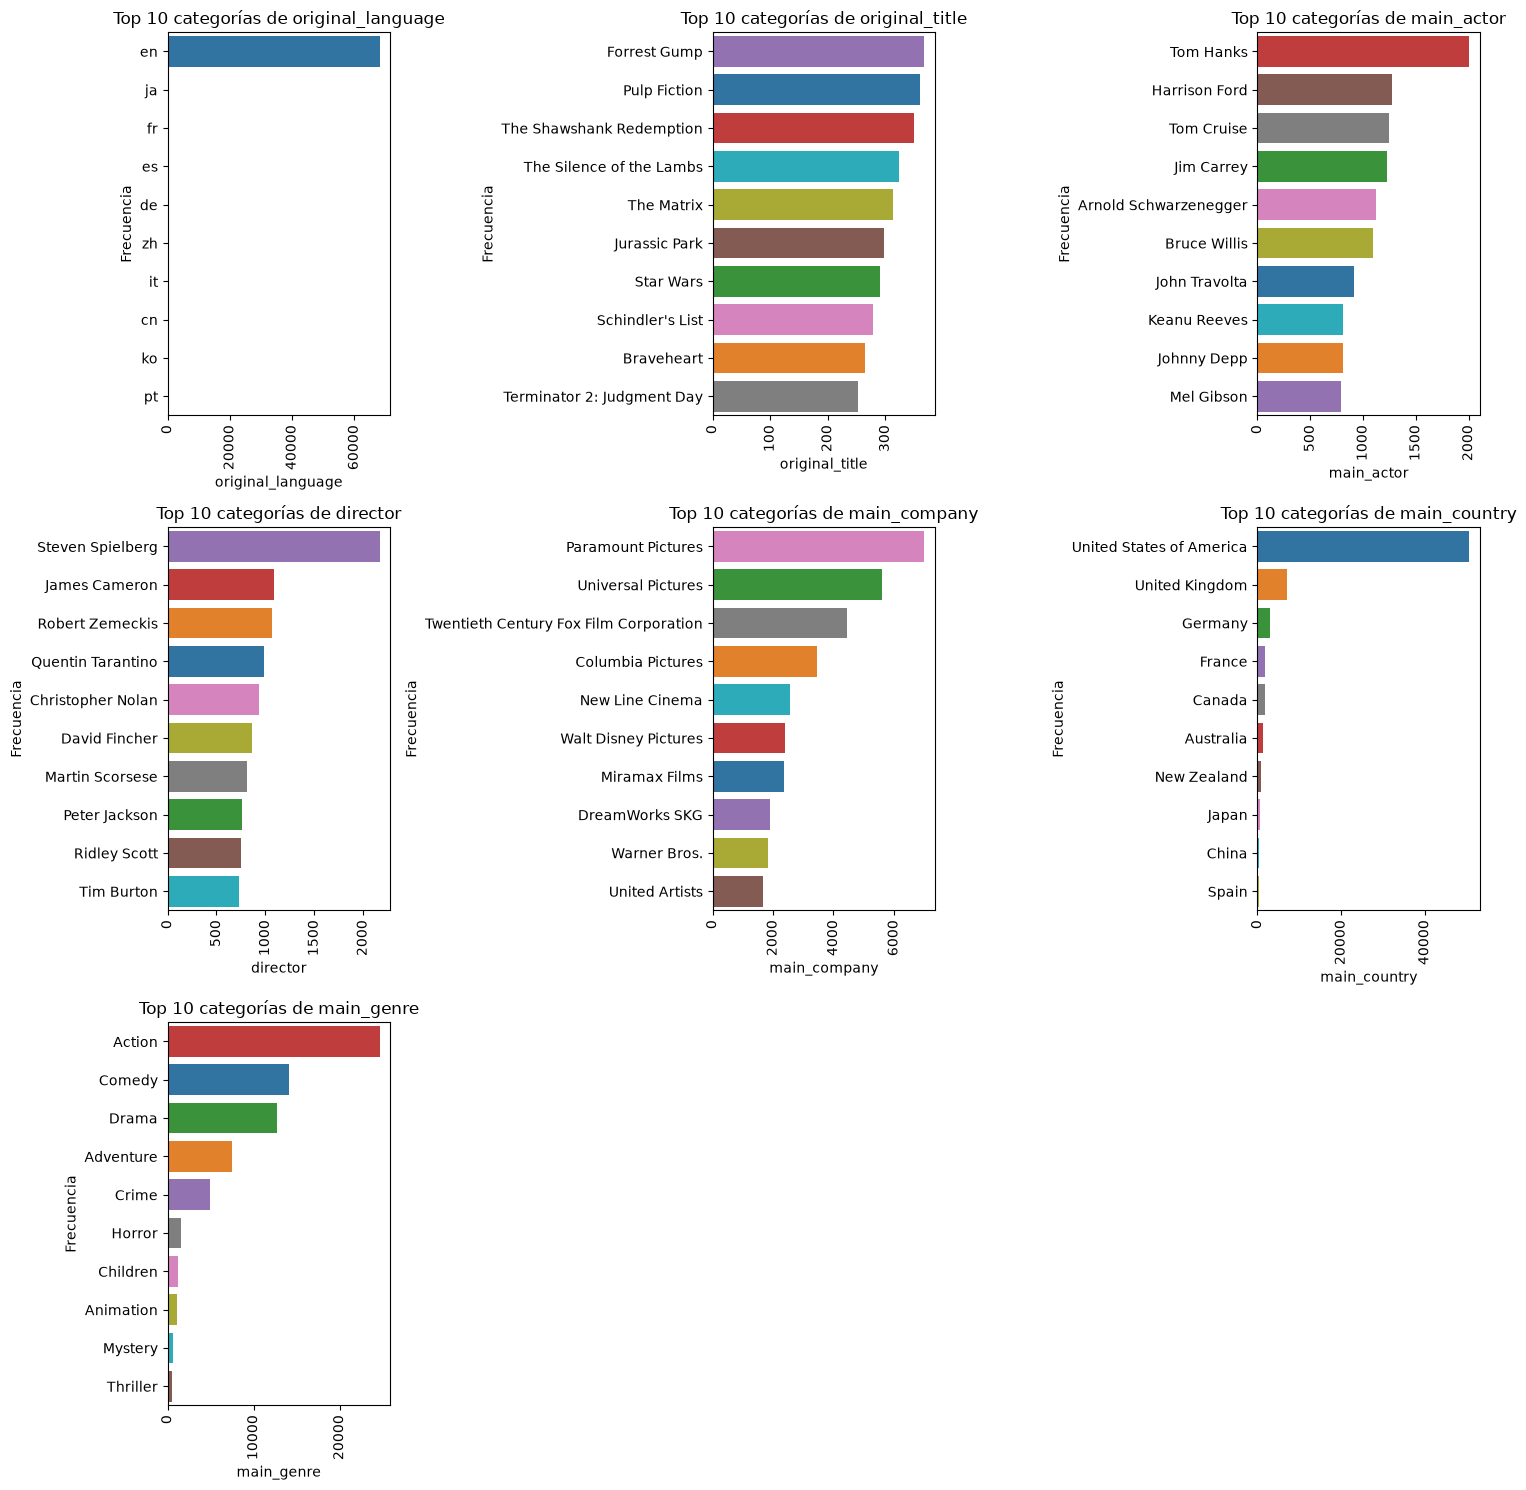

In [100]:
subplot_col_cat(df_2, ['original_language', 'original_title','main_actor', 'director', 'main_company', 'main_country', 'main_genre'])

Las variables categóricas muestran una clara concentración en determinadas categorías. El idioma original está dominado por el inglés (en), seguido a bastante distancia por japonés y francés. Entre los actores, directores y productoras destacan figuras y compañías muy reconocidas, como Tom Hanks, Steven Spielberg y Paramount Pictures. Estados Unidos es con diferencia el país con mayor representación. En cuanto al género, Action es el más frecuente, seguido de Comedy y Drama. En general, los datos presentan una fuerte concentración en determinadas categorías, especialmente en idioma, país y género.

In [102]:
nulos = df_2.isnull().mean()*100
nulos.sort_values(ascending=False).head()

homepage     58.698571
movieId       0.000000
rating        0.000000
timestamp     0.000000
userId        0.000000
dtype: float64

La única columna de valores nulos que tenemos en "homepage" dado el porcentaje de nulos introducimos la categoria "Unknown" para estos

In [103]:
df_2["homepage"] = df_2["homepage"].fillna("Unknown")

In [104]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             70000 non-null  str           
 1   movieId            70000 non-null  str           
 2   rating             70000 non-null  float64       
 3   timestamp          70000 non-null  datetime64[ns]
 4   genres_x           70000 non-null  str           
 5   imdbId             70000 non-null  str           
 6   tmdbId             70000 non-null  str           
 7   budget             70000 non-null  float64       
 8   homepage           70000 non-null  str           
 9   id                 70000 non-null  str           
 10  keywords           70000 non-null  str           
 11  original_language  70000 non-null  str           
 12  original_title     70000 non-null  str           
 13  popularity         70000 non-null  float64       
 14  release_date     

Por ultimo volvemos a comprobar la columna "timestamp" ya que se ha modificado con un valor erroneo

In [105]:
df_2["timestamp"].value_counts().sort_index()

timestamp
1970-01-01 00:00:00.828163431     4
1970-01-01 00:00:00.828163432     7
1970-01-01 00:00:00.828163637     1
1970-01-01 00:00:00.828444000    23
1970-01-01 00:00:00.828444001    12
                                 ..
1970-01-01 00:00:01.574194789     1
1970-01-01 00:00:01.574195101     1
1970-01-01 00:00:01.574253696     1
1970-01-01 00:00:01.574253719     1
1970-01-01 00:00:01.574253749     1
Name: count, Length: 57703, dtype: int64

In [106]:
df_2["timestamp"] = df_2["timestamp"].astype("int64")

In [107]:
df_2["timestamp"].value_counts().sort_index()

timestamp
828163431      4
828163432      7
828163637      1
828444000     23
828444001     12
              ..
1574194789     1
1574195101     1
1574253696     1
1574253719     1
1574253749     1
Name: count, Length: 57703, dtype: int64

In [108]:
df_2["timestamp"] = pd.to_datetime(df_2["timestamp"], unit="s")

In [109]:
df_2["timestamp"].head()

0   2006-05-17 15:34:04
1   2006-05-17 12:21:50
2   2006-05-17 12:20:14
3   2006-05-17 12:14:57
4   2006-05-17 12:14:39
Name: timestamp, dtype: datetime64[s]

Igualmente hay que volver a crear la columna "rating_year":

In [111]:
df_2["rating_year"] = df_2["timestamp"].dt.year

In [116]:
df_2["rating_year"].sample(10)

21773    1996
33985    2013
62274    1996
31133    2011
62809    1997
49198    2015
32539    2015
11822    1996
12726    2016
43045    2018
Name: rating_year, dtype: int32

In [113]:
df_2.describe().T

,count,mean,min,25%,50%,75%,max,std
rating,70000.0,3.606986,0.5,3.0,4.0,4.5,5.0,1.045944
timestamp,70000,2008-08-08 22:26:46,1996-03-30 05:23:51,2001-06-30 20:20:20,2008-10-29 17:56:30,2015-11-16 19:59:30,2019-11-20 12:42:29,NaN
budget,70000.0,50193172.386386,1.0,15000000.0,33000000.0,70000000.0,380000000.0,49256671.662256
popularity,70000.0,50.849148,0.011697,21.189028,41.083914,66.169628,875.581305,50.658719
release_date,70000,1997-07-06 02:51:14.194285,1916-09-04 00:00:00,1993-12-25 00:00:00,1999-02-05 00:00:00,2004-07-15 00:00:00,2016-08-17 00:00:00,NaN
revenue,70000.0,250172775.690214,10.0,65977295.0,160638883.0,351583407.0,2787965087.0,274177001.15485
runtime,70000.0,119.482871,25.0,102.0,116.0,132.0,254.0,24.207403
vote_average,70000.0,6.964987,1.9,6.4,7.0,7.6,10.0,0.805331
vote_count,70000.0,2290.799571,1.0,548.75,1422.0,3313.0,13752.0,2372.46158
release_year,70000.0,1996.947171,1916.0,1993.0,1999.0,2004.0,2016.0,11.867062


In [117]:
df_2.to_csv("../Data/Raw/Output/04_data_final.csv", index=False)